# Utilities

In [1]:
from imports import *

# Assignment 

## Assignment 4.1

In [67]:
#TODO Build a proxi gradient step visualization
#TODO Build a gradient step visualization
train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')
examples = enumerate(train)
_, (x_clean_example, x_noisy_example, labels_example) = next(examples)

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
C:\Users\The Cristi\AppData\Local\Temp\ipykernel_8556\1658719758.py:3: SyntaxWarning: invalid escape sequence '\D'
  train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')


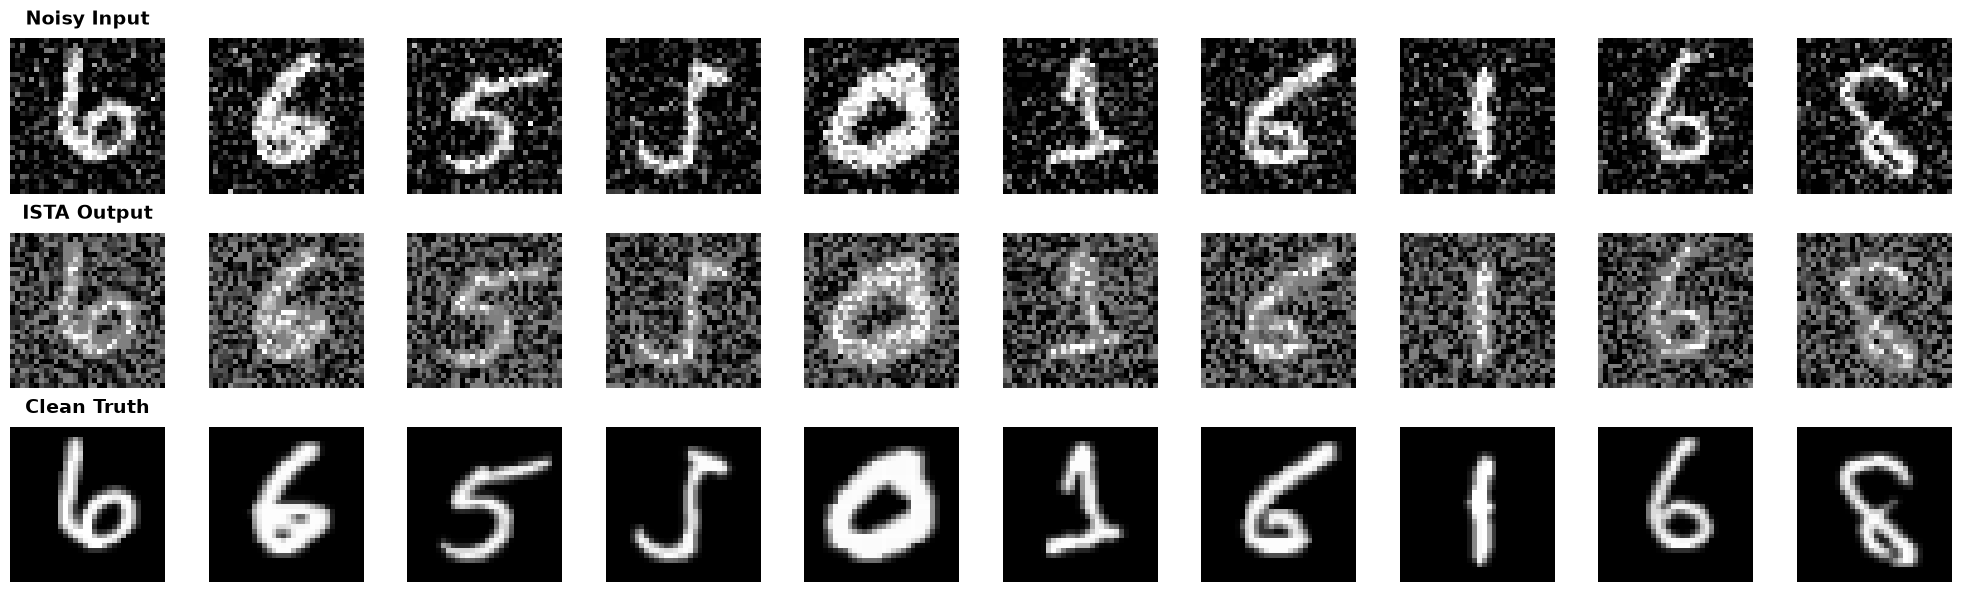

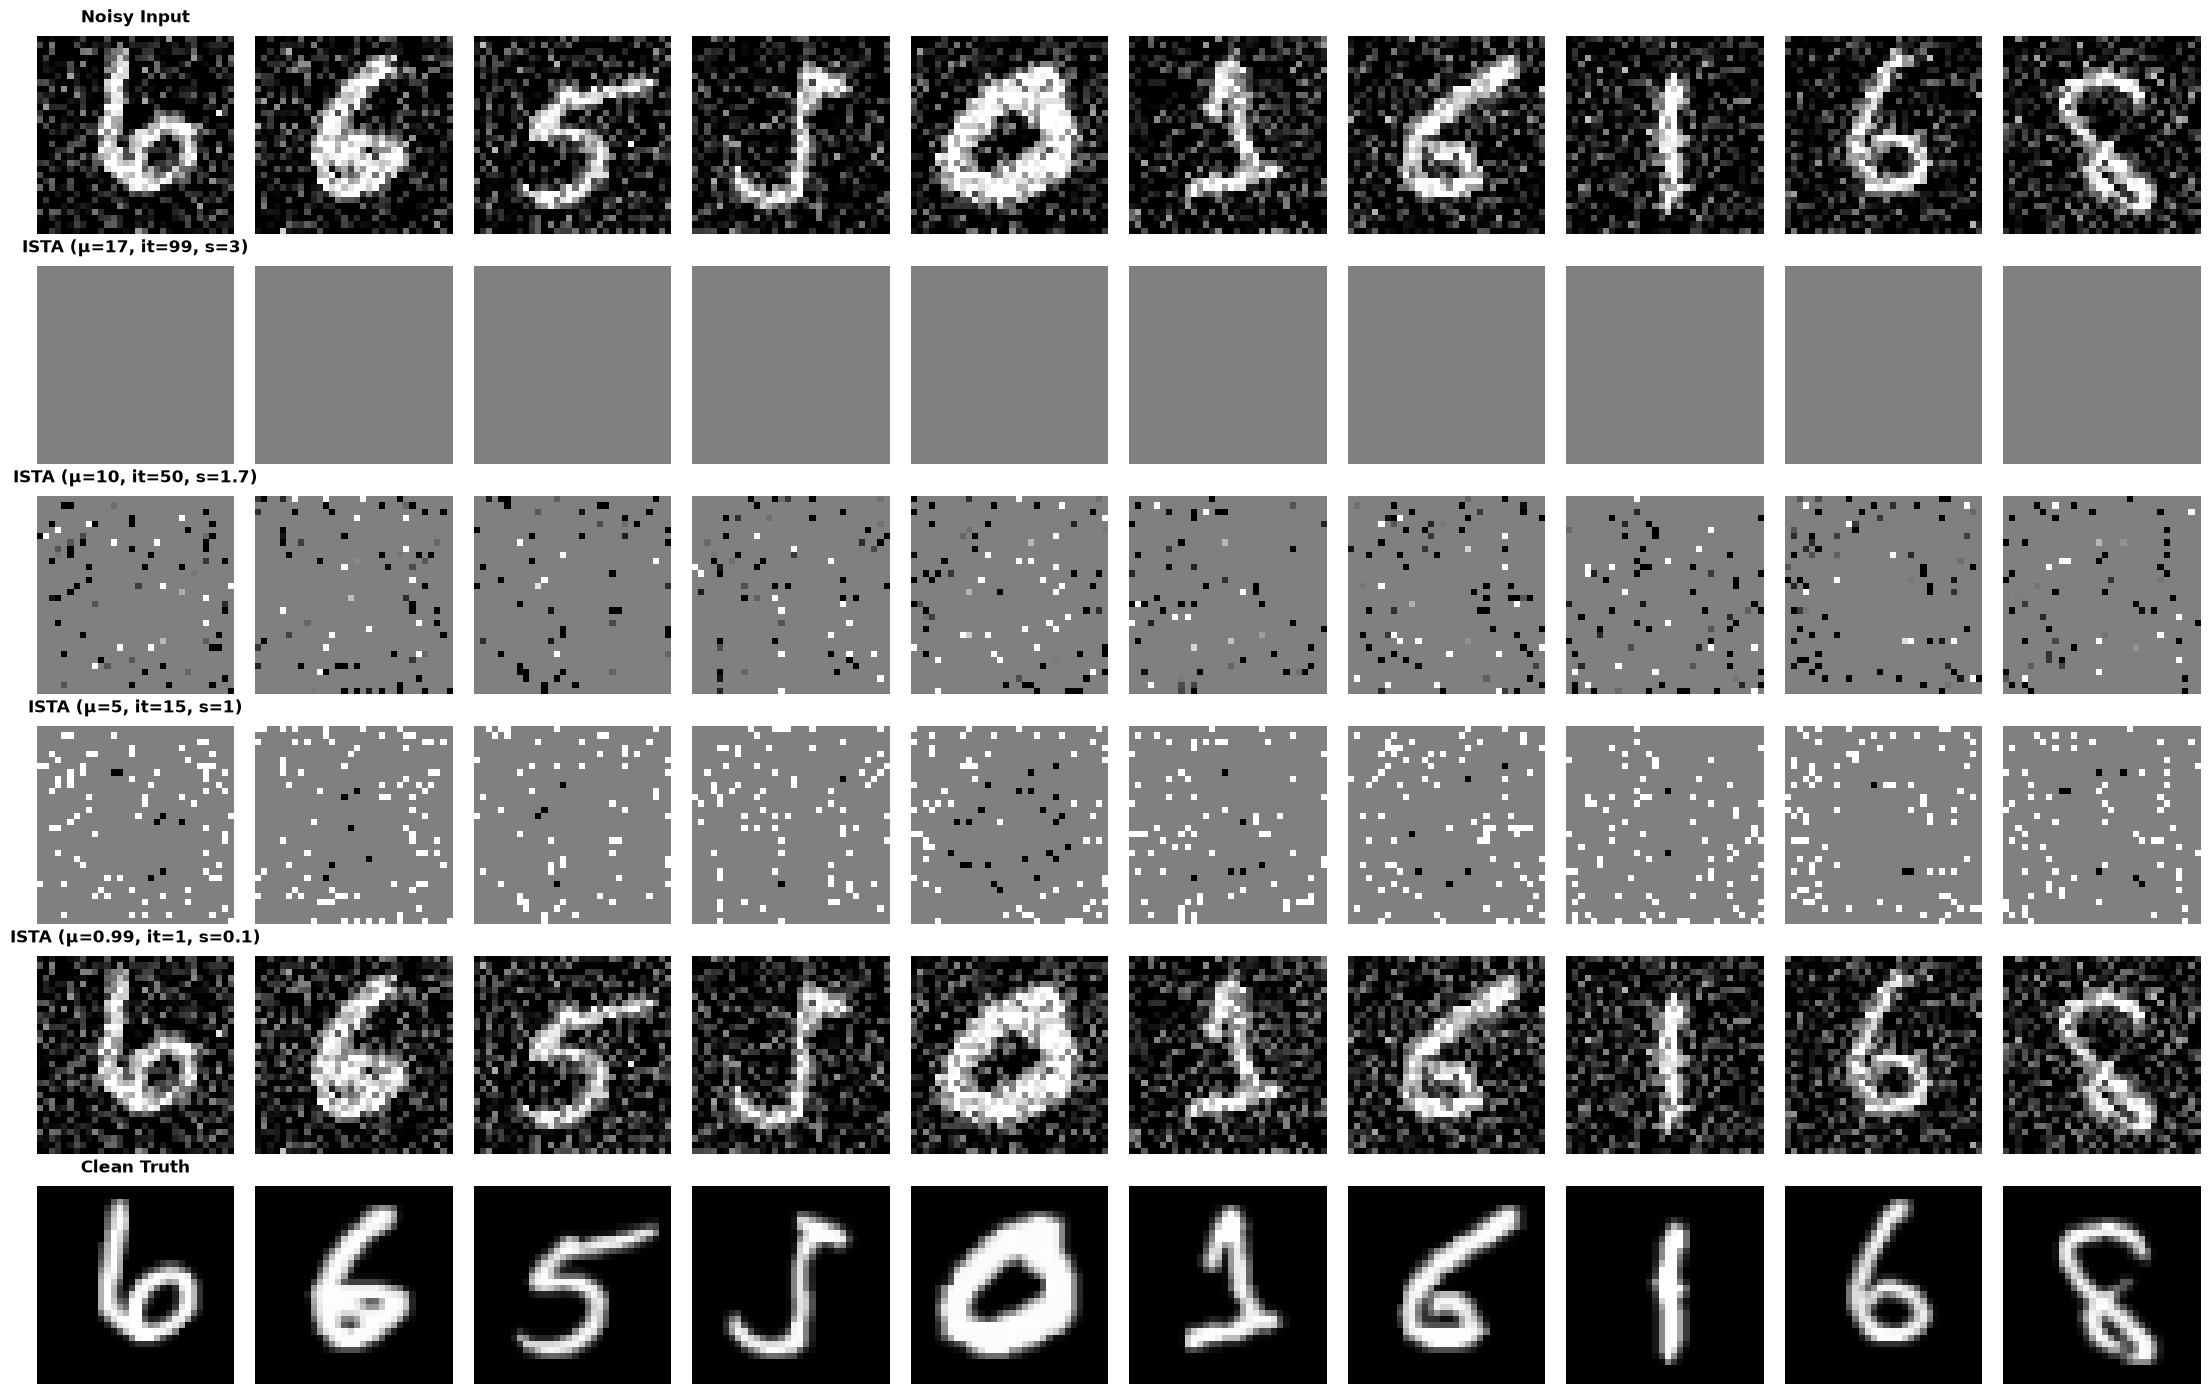

Regular value range of the images is max:1.0 and min:-1.0


In [ ]:
# 1. Perform ISTA
#TODO Make this perform denoising task as well
ista_reconstructions = ista(miu=5, shrink=0.1, no_iterations=1, y=x_noisy_example)

# 2. Define image-holders variables;
noisy_np = x_noisy_example.squeeze()
recon_np = ista_reconstructions.squeeze()
clean_np = x_clean_example.squeeze()

# Under the suboptimal suit of hyperparameters (that includes both miu/step size and shrinkage/threshold) 
# increasing the number of iterations will do nothing else but to hinder and make the convergence divert even more from 
# the optimal course. The contrary is applicable. Under the optimal pair of hyperparameters, the number of iterations will not change the quality of the solution
# as the convergence was guaranted from the very beginning.
# Based on heuristic experimentation, I discovered that the convergence is mostly influenced by the shrinkage value, which should be lowered until 
# the point the thresholding interval is encapsulated by the measurement matrix interval (e.g., maximum and minimium pixel values fall outside of the thresholding
# limits). Once the optimal shrinking limit was identified corrupting the quality of the solution can be done by adopting a very exagerated value for miu (~ the step-size),
# that is large enough to create a significant departure from the found solution. Not only this effect gets amplified as the miu value grows larger but also
# worsen with increasing the number of iterations that make for an erornous extended walk (e.g., more steps) 

# Assuming x_noisy_example and x_clean_example are already loaded from your dataset
#TODO Document the behavior of the ista based on the parameters;


# Pull tensors back to CPU and convert to numpy for Matplotlib
#TODO Document the function again based on your commentaries
#TODO Dismantled extraneous code commands (e.g., squezee())

# 3. Displaying required results
fig, axes = PLT.subplots(nrows=3, ncols=10, figsize=(20, 6))
for i in range(10):
    # ROW 1: Noisy Measurement (y)
    axes[0, i].imshow(noisy_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Noisy Input", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 2: ISTA Reconstruction (x_K)
    axes[1, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("ISTA Output", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 3: Ground Truth Target (x)
    axes[2, i].imshow(clean_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Clean Truth", fontsize=14, fontweight='bold', pad=10)

PLT.tight_layout()
PLT.show()

# 4. Defining the experiment-setting variable holders and 
# ...displaying experimental results
miu:list = [17, 10, 5, 0.99]
no_iterations:list = [99, 50, 15, 1]
shrink:list = [3, 1.7, 1, 0.1]

# 4.1 Setup a clean grid: 1 Row for Noisy, 4 Rows for Experiments, 1 Row for Clean Truth = 6 Rows total
fig, axes = PLT.subplots(nrows=6, ncols=10, figsize=(22, 14))
for i in range(10):
    # ROW 0: Noisy Measurement (y)
    axes[0, i].imshow(noisy_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    if i == 0: 
        axes[0, i].set_title("Noisy Input", fontsize=12, fontweight='bold', pad=10)

    # ROW 5: Ground Truth Target (x)
    axes[5, i].imshow(clean_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[5, i].axis('off')
    if i == 0: 
        axes[5, i].set_title("Clean Truth", fontsize=12, fontweight='bold', pad=10)

for experiments in range(4):
    # FIXED: accurately passed shrink=shrink[experiments] instead of duplicating miu
    ista_reconstructions = ista(
        miu=miu[experiments], 
        shrink=shrink[experiments], 
        no_iterations=no_iterations[experiments], 
        y=x_noisy_example
    )
    
    # Safely detach and squeeze if dealing with PyTorch tensors
    recon_np = ista_reconstructions.detach().cpu().numpy().squeeze() if hasattr(ista_reconstructions, 'detach') else ista_reconstructions.squeeze()

    # Calculate active row (Rows 1, 2, 3, and 4 are reserved for the 4 experiments)
    current_row = experiments + 1

    for i in range(10):
        axes[current_row, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
        axes[current_row, i].axis('off')
        
        if i == 0:
            title_text = f"ISTA (μ={miu[experiments]}, it={no_iterations[experiments]}, s={shrink[experiments]})"
            axes[current_row, i].set_title(title_text, fontsize=12, fontweight='bold', pad=10)

PLT.tight_layout()
PLT.show()

# Informative print;
print("Regular value range of the images is max:{} and min:{}".format(x_clean_example.max(), x_clean_example.min()))

# Helpers or standalone methods

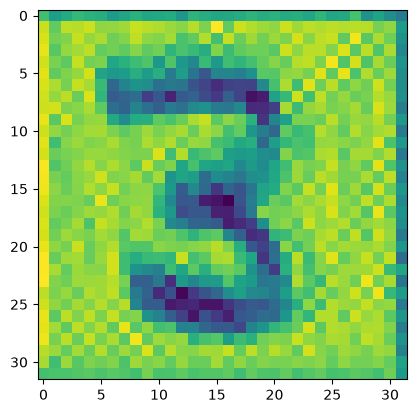

In [64]:
class LISTA(nn.Module):
    def __init__(self, in_c, out_c, k):
        super().__init__()
        self.in_channel = in_c
        self.out_channel = out_c
        self.no_folds = k
        self.network = nn.ModuleList() # In the nn.Sequential() container we do have the forward() method implementation but in the case of 
                                       # nn.ModuleList() this mechanism is absent therefore for each layer an explicit call is required;)
        # . By drawing upon a list comprehension mechanism separately defining the learnable convolutional matrices Wx and Wy becomes possible
        self.Wx = nn.ModuleList([nn.Conv2d(in_channels=self.in_channel, out_channels=self.out_channel, kernel_size=3, padding='same') for _ in range(self.no_folds)])
        self.Wy = nn.ModuleList([nn.Conv2d(in_channels=self.in_channel, out_channels=self.out_channel, kernel_size=3, padding='same') for _ in range(self.no_folds)])
        self.lambd = nn.Parameter(torch.randn(self.no_folds))

    def forward(self, x, y):
        for layer in range(self.no_folds):
            u = self.Wx[layer](x) + self.Wy[layer](y)
            x  = self.shrinkage(x = u, lam = self.lambd[layer])
            
        return x 
    
    def shrinkage(self, x, lam):
        return x + 0.5 * (torch.sqrt((x-lam)**2+1)-torch.sqrt((x+lam)**2+1))
    
# Testing
model = LISTA(in_c=1, out_c=1, k=3)
batch_sample = next(enumerate(train))
batch_idx, (clean, noisy, label) = batch_sample
ista_reconstructions=model(noisy, clean)
PLT.imshow(ista_reconstructions[0].detach().squeeze())


In [77]:
# TODO Create parser
train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')
model = LISTA(1, 1, 3)
optim = SGD(model.parameters(), lr=0.001) 
loss_fn = nn.MSELoss()
epochs:int = 10
train_history, val_history = [], []

for epoch in range(epochs):
    ### 1. Training == ######
    # Initializing training #                    
    ############### == ######
    model.train()
    reconstruction_acc_train, reconstruction_acc_val = 0.0 ,0.0
    for batch_idx, (x_clean, x_noisy, label) in enumerate(tqdm.tqdm(train, desc=f"Epoch {epoch+1}/{epochs} [Train]")):
        optim.zero_grad() # 1.1 Cleaning gradient cache memory;
        # 1.2
        # y is the measurement (noisy image). 
        # x is the initial state. The typical initialization is x_0 = 0.
        x_init = torch.zeros_like(x_noisy)
        _rec = model(x=x_init, y=x_noisy)
        # You correctly mapped the supervised target to x_clean!
        _loss = loss_fn(_rec, x_clean)
        # 1.3
        # Calculate the gradients and update the weights
        _loss.backward()
        optim.step()
        
        reconstruction_acc_train+=_loss.item()

    ### 2. Validation == #######
    # Initializing validation ##                    
    ############### == #########
    model.eval()
    with torch.no_grad():
        for batch_idx, (x_clean, x_noisy, label) in enumerate(tqdm.tqdm(valid, desc=f"Epoch {epoch+1}/{epochs} [Valid]")): 
            
            # Apply the same initialization fixes to the validation loop
            x_init = torch.zeros_like(x_noisy)
            _rec = model(x=x_init, y=x_noisy)
            
            _loss = loss_fn(_rec, x_clean)
            reconstruction_acc_val+=_loss.item()

    batch_rec_acc_train = reconstruction_acc_train/len(train)
    train_history.append(batch_rec_acc_train)
    batch_rec_acc_valid = reconstruction_acc_val/len(valid)
    val_history.append(batch_rec_acc_valid)
    
    # Minor formatting fix: displaying epoch+1 so it reads 1-10 instead of 0-9
    print(f"Epoch {epoch+1}: Train Averaged MSELoss {batch_rec_acc_train:.4f} | Valid Averaged MSELoss {batch_rec_acc_valid:.4f}")

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\The Cristi\AppData\Local\Temp\ipykernel_8556\1963728294.py:2: SyntaxWarning: invalid escape sequence '\D'
  train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')
Epoch 1/10 [Valid]: 100%|██████████| 157/157 [00:01<00:00, 113.90it/s]


Epoch 1: Train Averaged MSELoss 0.2332 | Valid Averaged MSELoss 0.0688


Epoch 2/10 [Valid]: 100%|██████████| 157/157 [00:01<00:00, 110.81it/s]


Epoch 2: Train Averaged MSELoss 0.0611 | Valid Averaged MSELoss 0.0560


Epoch 3/10 [Valid]: 100%|██████████| 157/157 [00:01<00:00, 107.75it/s]


...

Epoch 8: Train Averaged MSELoss 0.0467 | Valid Averaged MSELoss 0.0463


Epoch 9/10 [Valid]: 100%|██████████| 157/157 [00:01<00:00, 102.49it/s]


Epoch 9: Train Averaged MSELoss 0.0461 | Valid Averaged MSELoss 0.0456


Epoch 10/10 [Valid]: 100%|██████████| 157/157 [00:01<00:00, 118.73it/s]

Epoch 10: Train Averaged MSELoss 0.0455 | Valid Averaged MSELoss 0.0451


In [ ]:
noisy_np = x_noisy_example.squeeze()
recon_np = ista_reconstructions.squeeze()
clean_np = x_clean_example.squeeze()
# 3. Displaying required results
fig, axes = PLT.subplots(nrows=3, ncols=10, figsize=(20, 6))
for i in range(10):
    # ROW 1: Noisy Measurement (y)
    axes[0, i].imshow(noisy_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Noisy Input", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 2: ISTA Reconstruction (x_K)
    axes[1, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("ISTA Output", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 3: Ground Truth Target (x)
    axes[2, i].imshow(clean_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Clean Truth", fontsize=14, fontweight='bold', pad=10)

PLT.tight_layout()
PLT.show()

In [ ]:
@staticmethod
def ista(miu:float, shrink:float, no_iterations:int, y:torch.tensor, MODE='ISTA')->torch.tensor:

    # 1.1 Wrap the required definitions in a private function,
    # ... of the members used in both, gradient and proximal steps;
    def _proximal_elements_definition(measurement=y):
        A_def:float = 1.0
        L_def:float = 1.0
        # 1.2 Initialize the unknown signal X to match the measurement shape
        x_def = measurement.clone() 
        return L_def, A_def, x_def
        
    L, A, X = _proximal_elements_definition() # L is required to define the threshold

    # 2.1 Defining shrinkage function
    def shrinkage_fn(current_x, lambd=shrink, measurement=y):
        # 2.2 Incorporating the required step size `miu` into the scalar terms
        W_y = miu * A 
        W_x = 1.0 - (miu * A * A)
        theta = lambd * miu

        # 2.3 ReLU definition wrapped in a private function;
        # Matrix multiplications (@) replaced with scalar multiplications (*)
        u = W_y * measurement + W_x * current_x
        
        # Accommodating the -1 background hint natively
        u_shifted = u + 1.0 
        
        # Using F.relu to cleanly process the maximum condition
        rec = F.relu(u - theta) - F.relu(-u - theta)
        
        # Shift back to the -1 background
        # rec = rec - 1.0

        return rec, (W_y, W_x, theta)

    for iter in range(no_iterations):
        # Update the evolving signal X, while keeping the original measurement y fixed
        X, _ = shrinkage_fn(current_x=X)

    return X